In [ ]:
# Dataset path (local folder with 8 types of leaves)
# Update this path if your dataset location changes
dataset_path = r"C:\Users\singh\Desktop\8th_project\1"

# Dataset setup
Load the image dataset, create train/validation/test splits, and prepare dataset performance settings.

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow as tf  # Added tf import for cardinality

# Define parameters for loading the dataset
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Dataset path (local folder with 8 types of leaves)
dataset_path = r"C:\Users\singh\Desktop\8th_project\1"

# Create training, validation, and test datasets
# Using an 80-10-10 split for train, validation, and test
seed_value = 42  # for reproducibility

# Load training dataset (80%)
train_ds = image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=seed_value,
    validation_split=0.2,  # 20% for validation + test
    subset='training'  # Specify 'training' subset
)

# Load validation dataset (10%)
val_ds = image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=seed_value,
    validation_split=0.2,
    subset='validation'
)

# Determine the number of validation batches for a 10% split for validation and 10% for test
val_batches = tf.data.experimental.cardinality(val_ds)
# Safely convert cardinality tensor to a Python int (works in eager mode)
try:
    val_batches = int(val_batches.numpy())
except Exception:
    val_batches = int(val_batches)

test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print(f"Number of training batches: {int(tf.data.experimental.cardinality(train_ds).numpy())}")
print(f"Number of validation batches: {int(tf.data.experimental.cardinality(val_ds).numpy())}")
print(f"Number of test batches: {int(tf.data.experimental.cardinality(test_ds).numpy())}")

# Get class names and number of classes
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Class Names:", class_names)
print("Number of Classes:", NUM_CLASSES)

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 4000 files belonging to 8 classes.
Using 3200 files for training.
Found 4000 files belonging to 8 classes.
Using 800 files for validation.
Number of training batches: 100
Number of validation batches: 13
Number of test batches: 12
Class Names: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Number of Classes: 8


# Model creation and transfer learning
Use MobileNetV2 as a feature extractor, add augmentation, and build the final classifier.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation, RandomZoom, RandomContrast
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Sequential
import tensorflow as tf  # Ensure tf is imported for keras.Input and mobilenet_v2.preprocess_input

# Data Augmentation Layer
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomContrast(0.2)
], name="data_augmentation")

# Create the base model from the pre-trained MobileNetV2
# We exclude the top classification layer (include_top=False)
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model to use its pre-trained features
base_model.trainable = False

# Create a new model on top of the pre-trained base
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = data_augmentation(inputs)

# Preprocess the input images for MobileNetV2 (scaling to [-1, 1])
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)  # Run the base model in inference mode
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)  # Add a dropout layer for regularization
outputs = Dense(NUM_CLASSES, activation='softmax')(x)  # Output layer with softmax

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss=SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

# Train the model with early stopping
EPOCHS = 30  # Train for 30 epochs

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping]
)

print("\nTraining complete. Evaluating model on test set...")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

✓ Network available. Loading pre-trained MobileNetV2 weights...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 240ms/step - accuracy: 0.7681 - loss: 0.7433 - val_accuracy: 0.9519 - val_loss: 0.2242
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 221ms/step - accuracy: 0.9559 - loss: 0.1864 - val_accuracy: 0.9688 - val_loss: 0.1390
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 218ms/step - accuracy: 0.9728 - loss: 0.1219 - val_accuracy: 0.9736 - val_loss: 0.1129
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 219ms/step - accuracy: 0.9762 - loss: 0.0975 - val_accuracy: 0.9760 - val_loss: 0.0801
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 217ms/step - accuracy: 0.9819 - loss: 0.0740 - val_accuracy: 0.9952 - val_loss: 0.0540
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 215ms/step - accuracy: 0.9825 - loss: 0.0673 - val_accuracy: 0.9880 - val_loss: 0.0538
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 217ms/step - accuracy: 0.9791 - loss: 0.0685 - val_accuracy: 0.9928 - val_loss: 0.0444
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 217ms/step - accuracy: 0.9862 - loss: 0

# Metrics and confusion matrix
Evaluate the test dataset and visualize classification performance.

--- Classification Report ---
                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        45
Bacterial Canker       1.00      1.00      1.00        53
  Cutting Weevil       1.00      1.00      1.00        42
        Die Back       1.00      1.00      1.00        48
      Gall Midge       1.00      1.00      1.00        36
         Healthy       1.00      1.00      1.00        52
  Powdery Mildew       0.96      0.98      0.97        53
     Sooty Mould       0.98      0.96      0.97        55

        accuracy                           0.99       384
       macro avg       0.99      0.99      0.99       384
    weighted avg       0.99      0.99      0.99       384



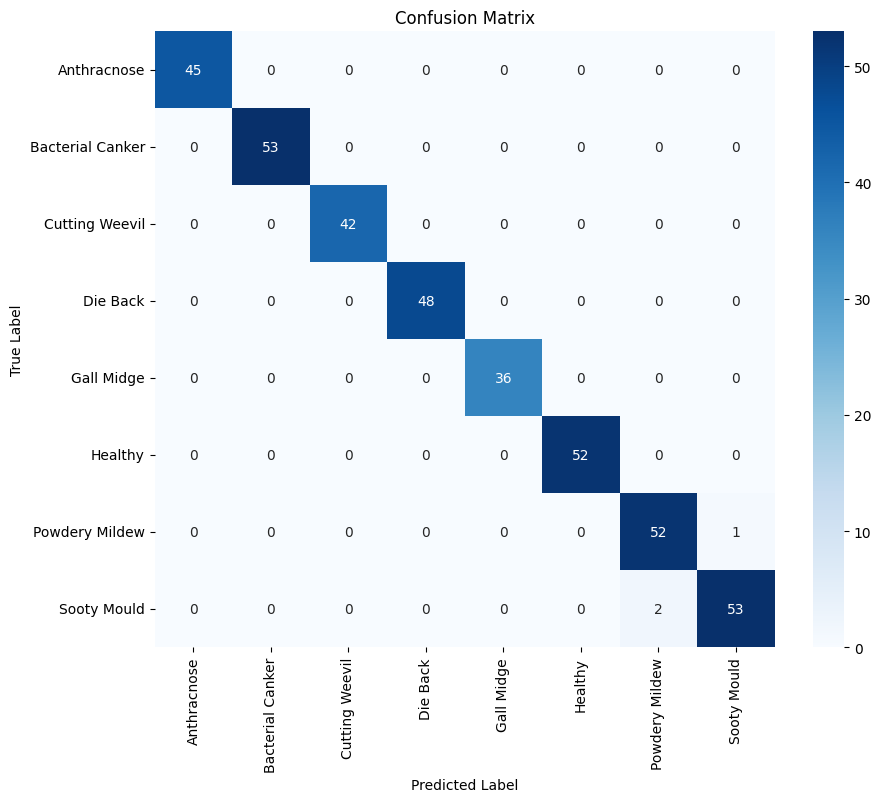

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels and predictions for the test dataset
# This evaluates the trained MobileNetV2 model on the held-out test split.
true_labels = []
predictions = []

for images, labels in test_ds:
    true_labels.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    predictions.extend(np.argmax(preds, axis=1))

true_labels = np.array(true_labels)
predictions = np.array(predictions)

print("--- Classification Report ---")
print(classification_report(true_labels, predictions, target_names=class_names))

# Generate confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Sample predictions example
Display a few test images with their true labels and predicted labels.

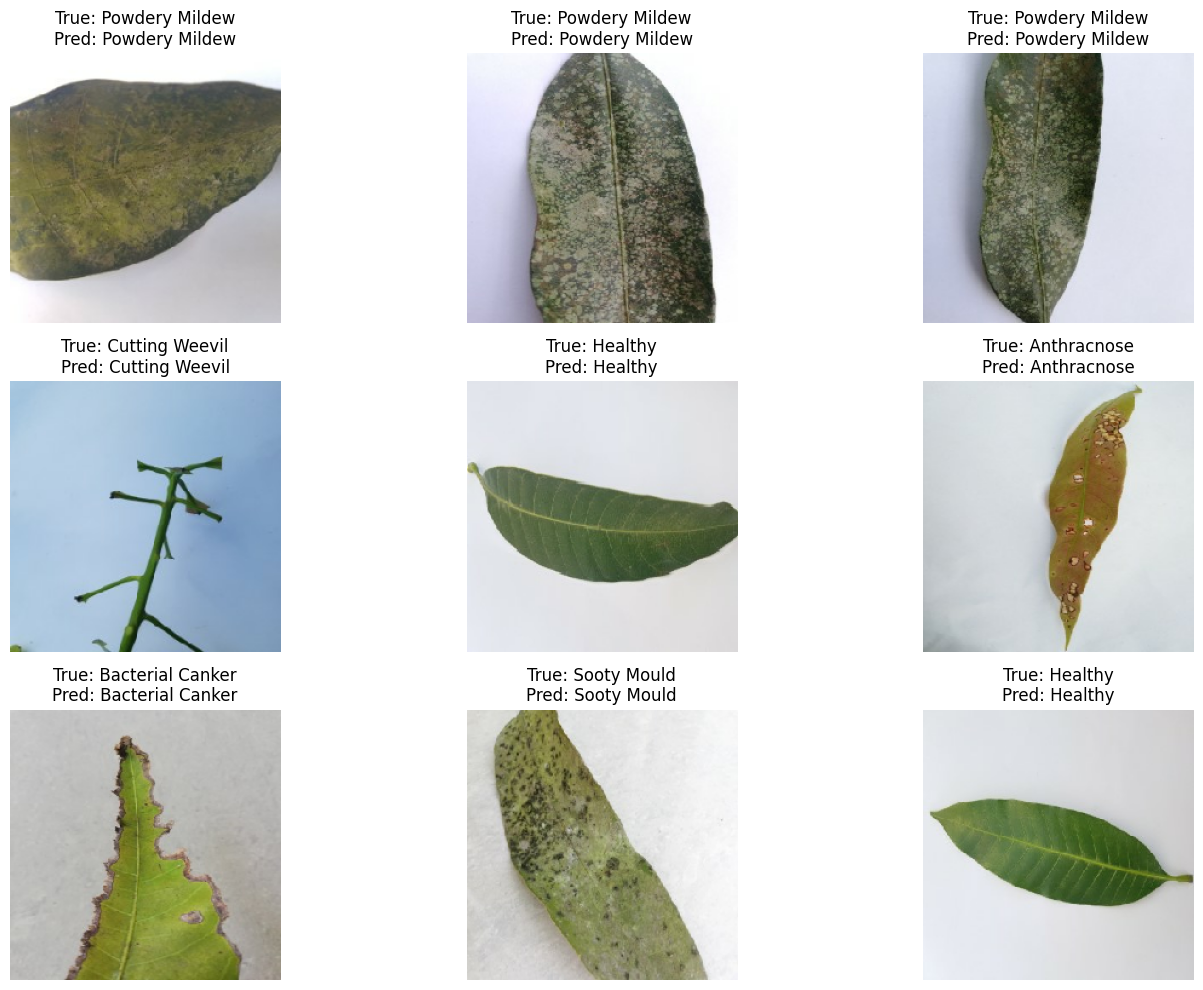

In [ ]:
plt.figure(figsize=(15, 10))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class = class_names[np.argmax(model.predict(tf.expand_dims(images[i], 0), verbose=0))]
        true_class = class_names[labels[i]]

        plt.title(f"True: {true_class}\nPred: {predicted_class}")
        plt.axis("off")
plt.tight_layout()
plt.show()

# Training history visualization
Plot training and validation accuracy/loss to verify model learning behavior.

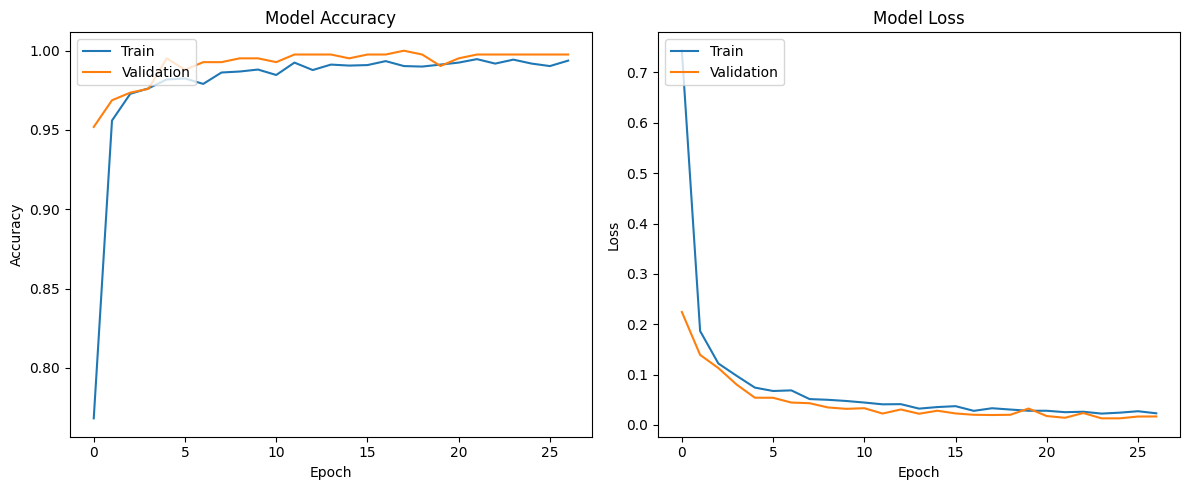

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()